In [1]:
import sys
# sys.path.append('/Users/mariana/Documents/projects/Huawei/survan')
sys.path.append('/home/mvargas/code/Huawei/survan')

from baseline_cox import SA
from utils import concordance_index, unroll, get_single_task_dataset
import yaml
import jax
import jax.numpy as jnp
import numpy as np
import haiku as hk
import matplotlib.pyplot as plt

In [2]:
def score(beta, xs):
    return -jnp.dot(xs, beta)

In [3]:
config_path = '../config.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [4]:
agent = SA(config, 42)

In [5]:
xs = agent.data['seqs']
ts = agent.data['ts']
cs = agent.data['cs']
y = agent.data['target']
mask = agent.data['mask']

n, H, _ = xs.shape
# xs = jnp.concatenate((xs, jnp.tile(jnp.eye(H), (n, 1, 1))), axis=-1)
# agent.integrated_brier_score(xs[:,0], ts, cs)

In [ ]:
%%time

num_exps = 5
sizes = [.5, .3, .2, .1]

res2_is = np.zeros((num_exps, len(sizes)))
res2_lm = np.zeros((num_exps, len(sizes)))
res2_td = np.zeros((num_exps, len(sizes)))

res3_is = np.zeros((num_exps, len(sizes)))
res3_lm = np.zeros((num_exps, len(sizes)))
res3_td = np.zeros((num_exps, len(sizes)))

for fold in range(num_exps):
    for i, size in enumerate(sizes):
        
        print(".", end="")
        
        # Initial state.
        config['landmark'] = False
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        res2_is[fold, i] = model.integrated_brier_score(seqs[:, 0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs[:, 0])
        res3_is[fold, i] = concordance_index(scores, ts, cs)
        
        # Landmarking.
        config['landmark'] = True
        model = SA(config, seed=fold)
        
        train_gen, test_gen = model.get_train_test(test_size=size)
        seqs = test_gen.X
        ts = test_gen.ts
        cs = test_gen.cs
        
        _ = model.train(train_gen, test_gen)
        res2_lm[fold, i] = model.integrated_brier_score(seqs[:, 0], ts, cs)
        beta = model.state.params['cox_linear_model']['beta']
        scores = score(beta, seqs[:, 0])
        res3_lm[fold, i] = concordance_index(scores, ts, cs)
        
    print()

....
.

Text(0.5, 0, 'Number of patients')

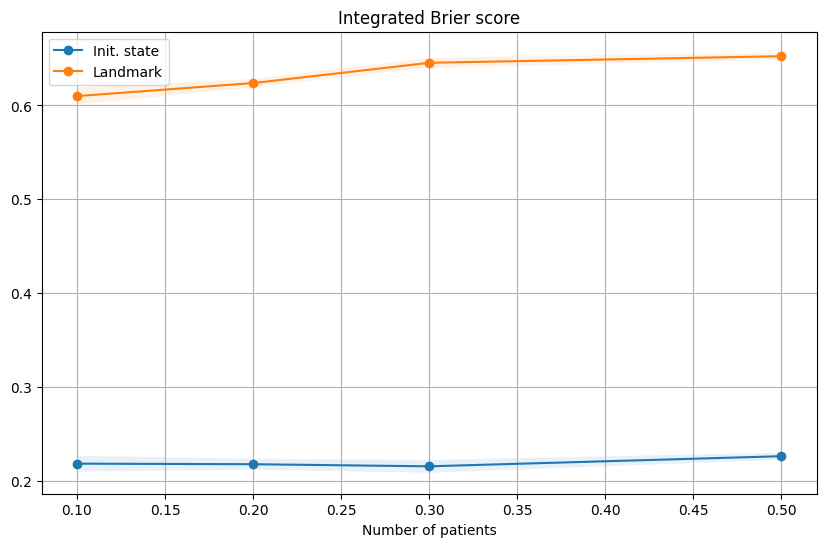

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res2_is, "Init. state"), (res2_lm, "Landmark")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Integrated Brier score")
ax.set_xlabel("Number of patients")

Text(0.5, 0, 'Number of patients')

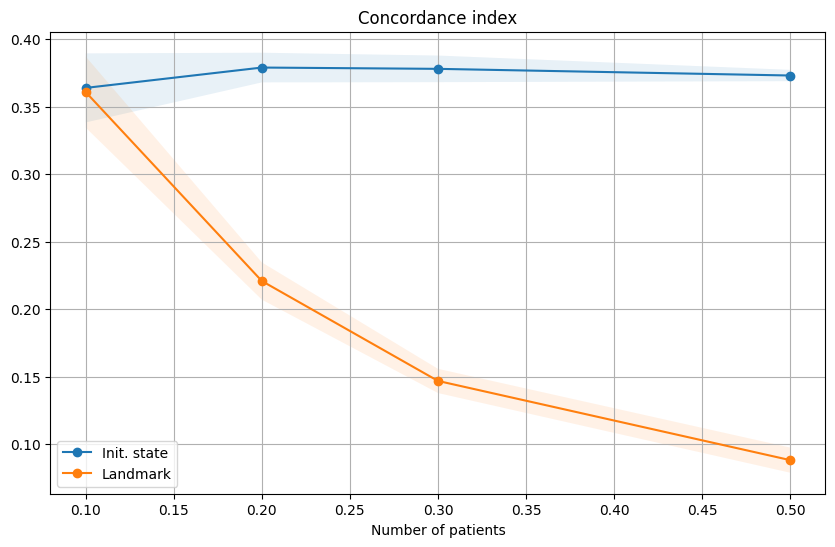

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

for res, label in ((res3_is, "Init. state"), (res3_lm, "Landmark")):
    mean = res.mean(axis=0)
    std = res.std(axis=0) / np.sqrt(num_exps)
    ax.plot(sizes, mean, marker="o", label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.1)

ax.legend()
ax.grid()
ax.set_title("Concordance index")
ax.set_xlabel("Number of patients")